In [14]:
import sys
sys.path.append('..')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from src.data_loader import DataLoader

loader = DataLoader(data_dir="../data")
df = pd.read_csv(loader.processed_dir / "cleaned_data.csv")

for col in ['species', 'island', 'sex']:
    df[col] = df[col].astype('category')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

os.makedirs('../reports/figures', exist_ok=True)

print(f"Loaded cleaned_data.csv: {df.shape}")
df.head()

Loaded cleaned_data.csv: (344, 9)


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_area_mm2,flipper_to_mass_ratio
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,MALE,731.170,0.048267
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,FEMALE,687.300,0.048947
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,FEMALE,725.400,0.060000
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,MALE,768.985,0.048642
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,FEMALE,708.310,0.055942


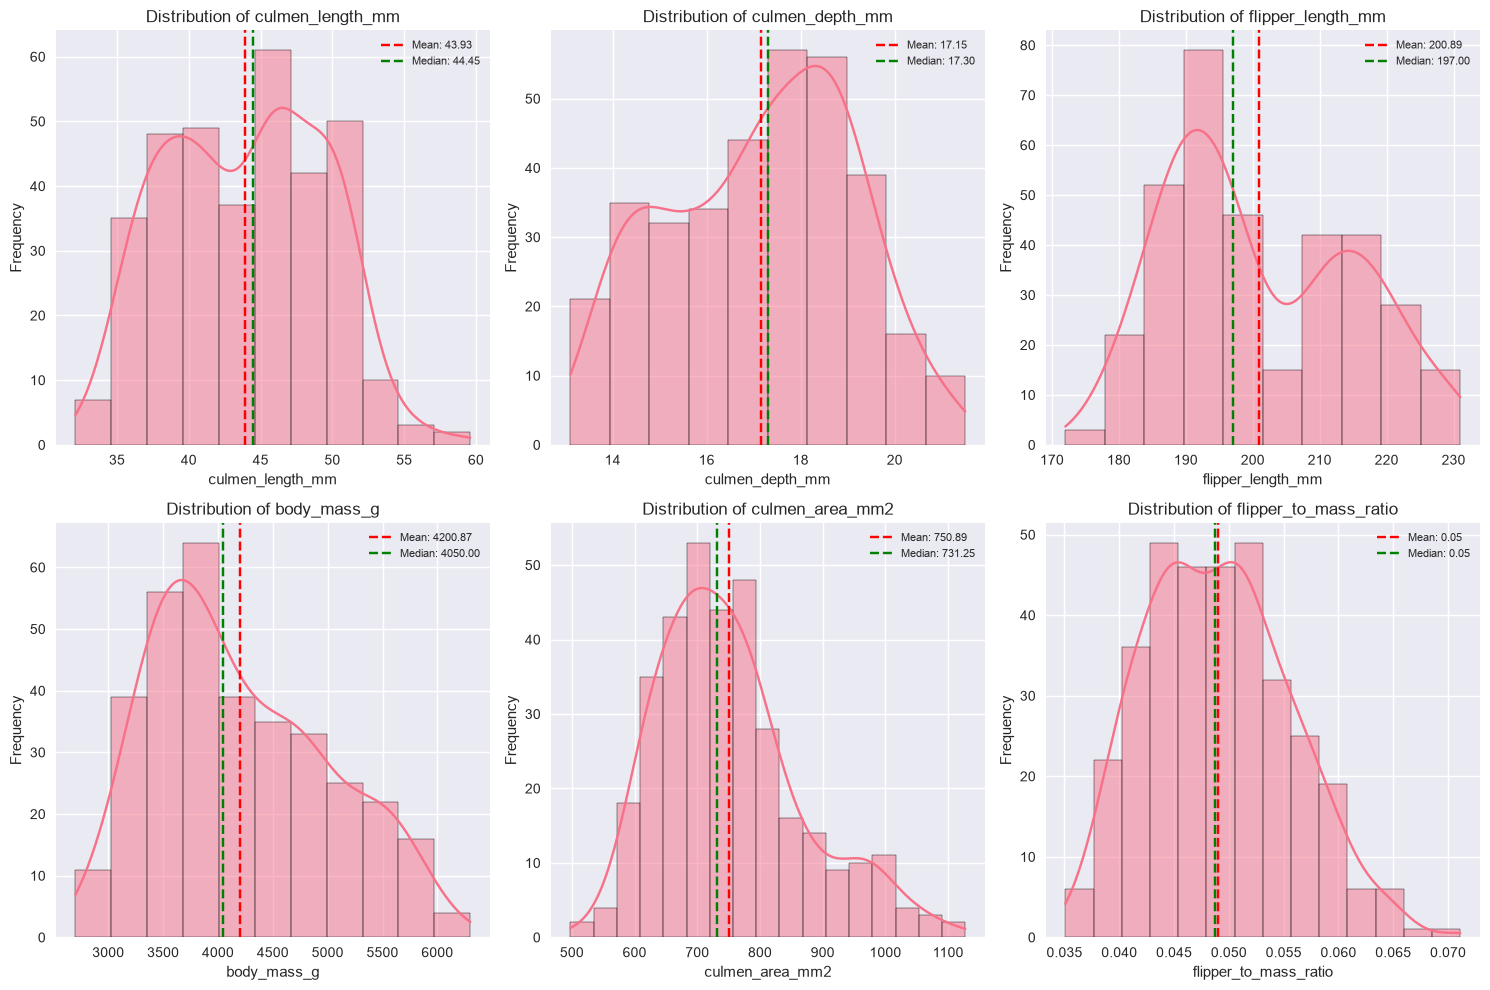

In [15]:
def create_distribution_plots(df: pd.DataFrame):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        data = df[col].dropna()
        sns.histplot(data, kde=True, ax=axes[idx])
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].axvline(data.mean(), color='red', linestyle='--',
                           label=f'Mean: {data.mean():.2f}')
        axes[idx].axvline(data.median(), color='green', linestyle='--',
                           label=f'Median: {data.median():.2f}')
        axes[idx].legend(fontsize=8)

    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.savefig('../reports/figures/distribution_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

create_distribution_plots(df)

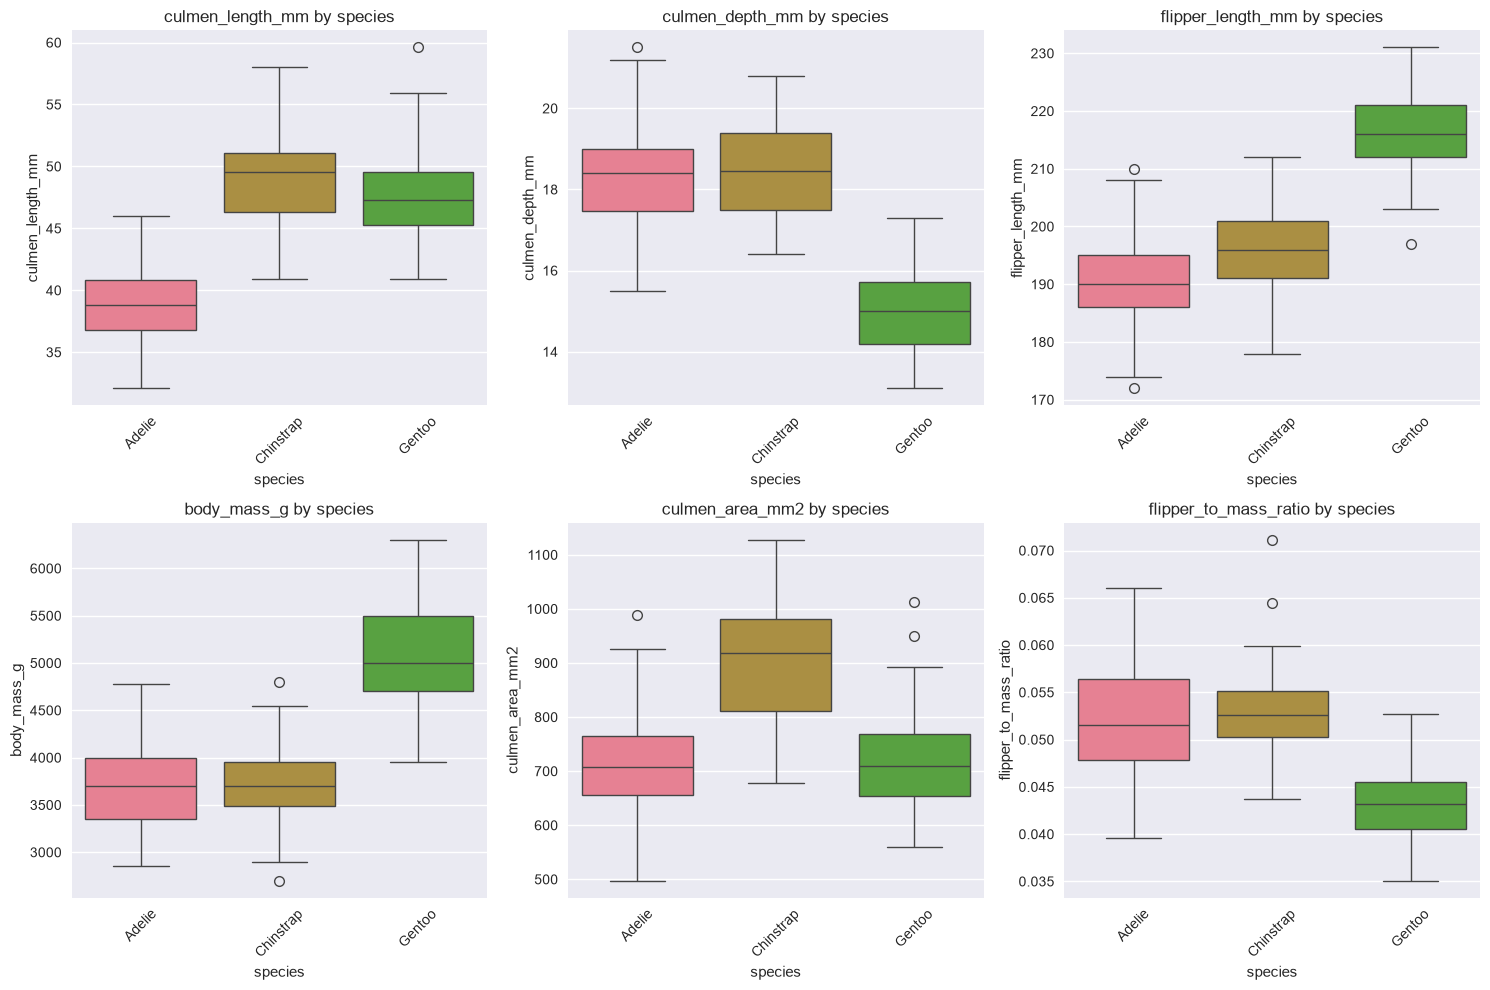

In [16]:
def create_boxplots(df: pd.DataFrame):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = df.select_dtypes(include=['category', 'object']).columns

    if len(categorical_cols) == 0:
        fig, axes = plt.subplots(1, min(4, len(numeric_cols)), figsize=(15, 5))
        if len(numeric_cols) == 1:
            axes = [axes]
        for idx, col in enumerate(numeric_cols[:4]):
            sns.violinplot(data=df[col].dropna(), ax=axes[idx])
            axes[idx].set_title(f'Distribution of {col}')
            axes[idx].set_ylabel(col)
        plt.tight_layout()
        plt.savefig('../reports/figures/violin_plots.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        cat_col = 'species' if 'species' in categorical_cols else categorical_cols[0]
        n_cols = 3
        n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        axes = axes.flatten()

        for idx, col in enumerate(numeric_cols):
            sns.boxplot(data=df, x=cat_col, y=col, ax=axes[idx], hue=cat_col, legend=False)
            axes[idx].set_title(f'{col} by {cat_col}')
            axes[idx].set_xlabel(cat_col)
            axes[idx].set_ylabel(col)
            axes[idx].tick_params(axis='x', rotation=45)

        for idx in range(len(numeric_cols), len(axes)):
            fig.delaxes(axes[idx])

        plt.tight_layout()
        plt.savefig('../reports/figures/boxplots.png', dpi=300, bbox_inches='tight')
        plt.show()

create_boxplots(df)

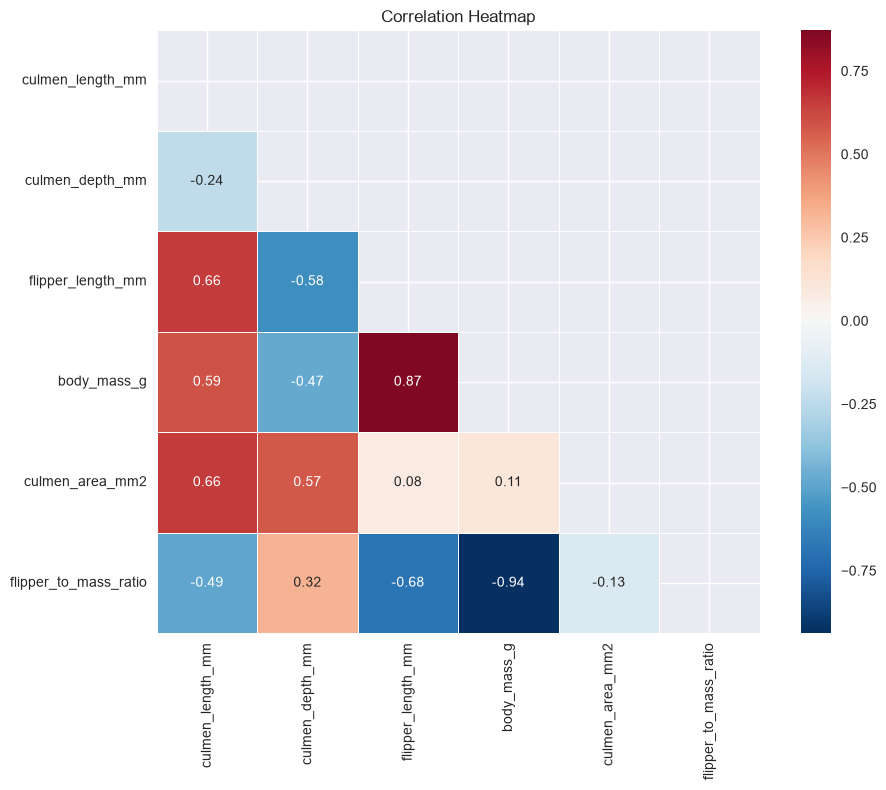

In [18]:
def create_correlation_heatmap(df: pd.DataFrame):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    corr = df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Correlation Heatmap')
    plt.tight_layout()
    plt.savefig('../reports/figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    return corr

corr_matrix = create_correlation_heatmap(df)

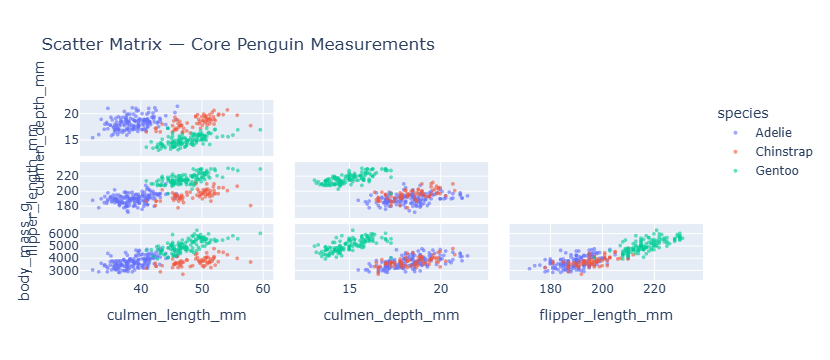

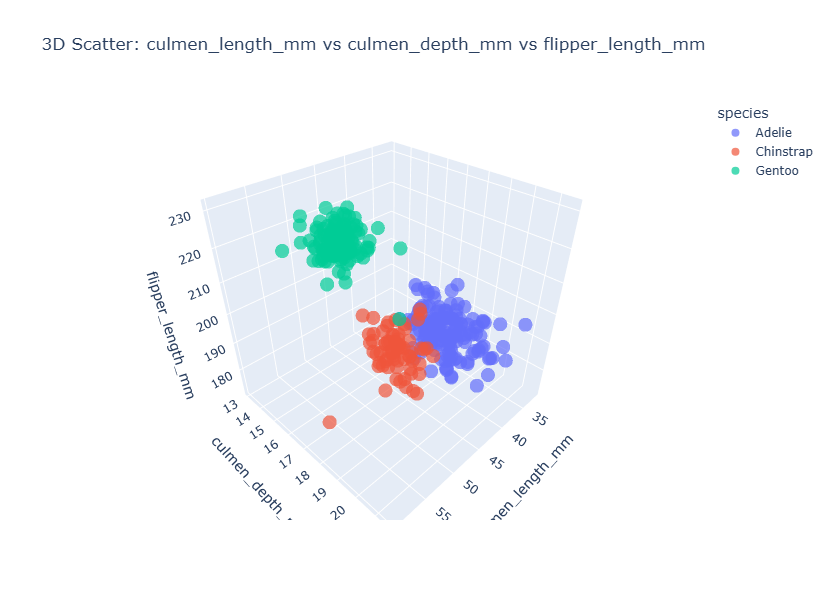

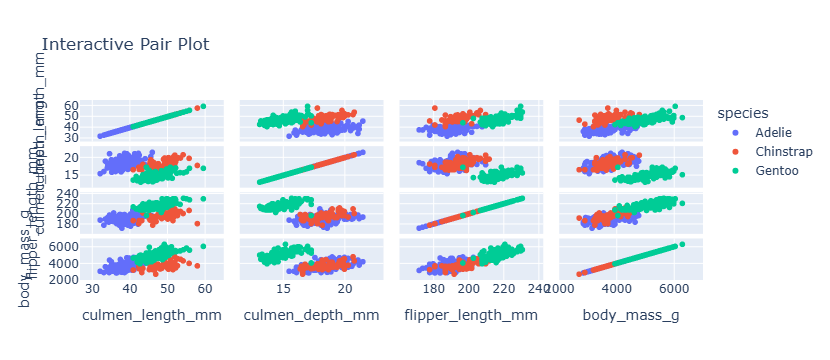

In [19]:
def create_interactive_plots(df: pd.DataFrame):
    numeric_cols = list(df.select_dtypes(include=['int64', 'float64']).columns)
    cat_cols = df.select_dtypes(include=['category', 'object']).columns
    color_col = 'species' if 'species' in cat_cols else (cat_cols[0] if len(cat_cols) > 0 else None)

    core_cols = [c for c in ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g'] if c in numeric_cols]

    if len(core_cols) > 1:
        fig = px.scatter_matrix(
            df, dimensions=core_cols, color=color_col,
            title="Scatter Matrix — Core Penguin Measurements"
        )
        fig.update_traces(diagonal_visible=False, showupperhalf=False, marker=dict(size=4, opacity=0.6))
        fig.write_html('../reports/figures/scatter_matrix.html')
        fig.show()

    if len(core_cols) >= 3:
        x_col, y_col, z_col = core_cols[:3]
        fig = px.scatter_3d(
            df, x=x_col, y=y_col, z=z_col, color=color_col,
            title=f"3D Scatter: {x_col} vs {y_col} vs {z_col}",
            opacity=0.7, width=800, height=600
        )
        fig.update_layout(scene=dict(xaxis_title=x_col, yaxis_title=y_col, zaxis_title=z_col))
        fig.write_html('../reports/figures/3d_scatter.html')
        fig.show()

    if len(core_cols) > 1:
        fig = px.scatter_matrix(
            df, dimensions=core_cols, color=color_col,
            title="Interactive Pair Plot"
        )
        fig.write_html('../reports/figures/pair_plot.html')
        fig.show()

create_interactive_plots(df)

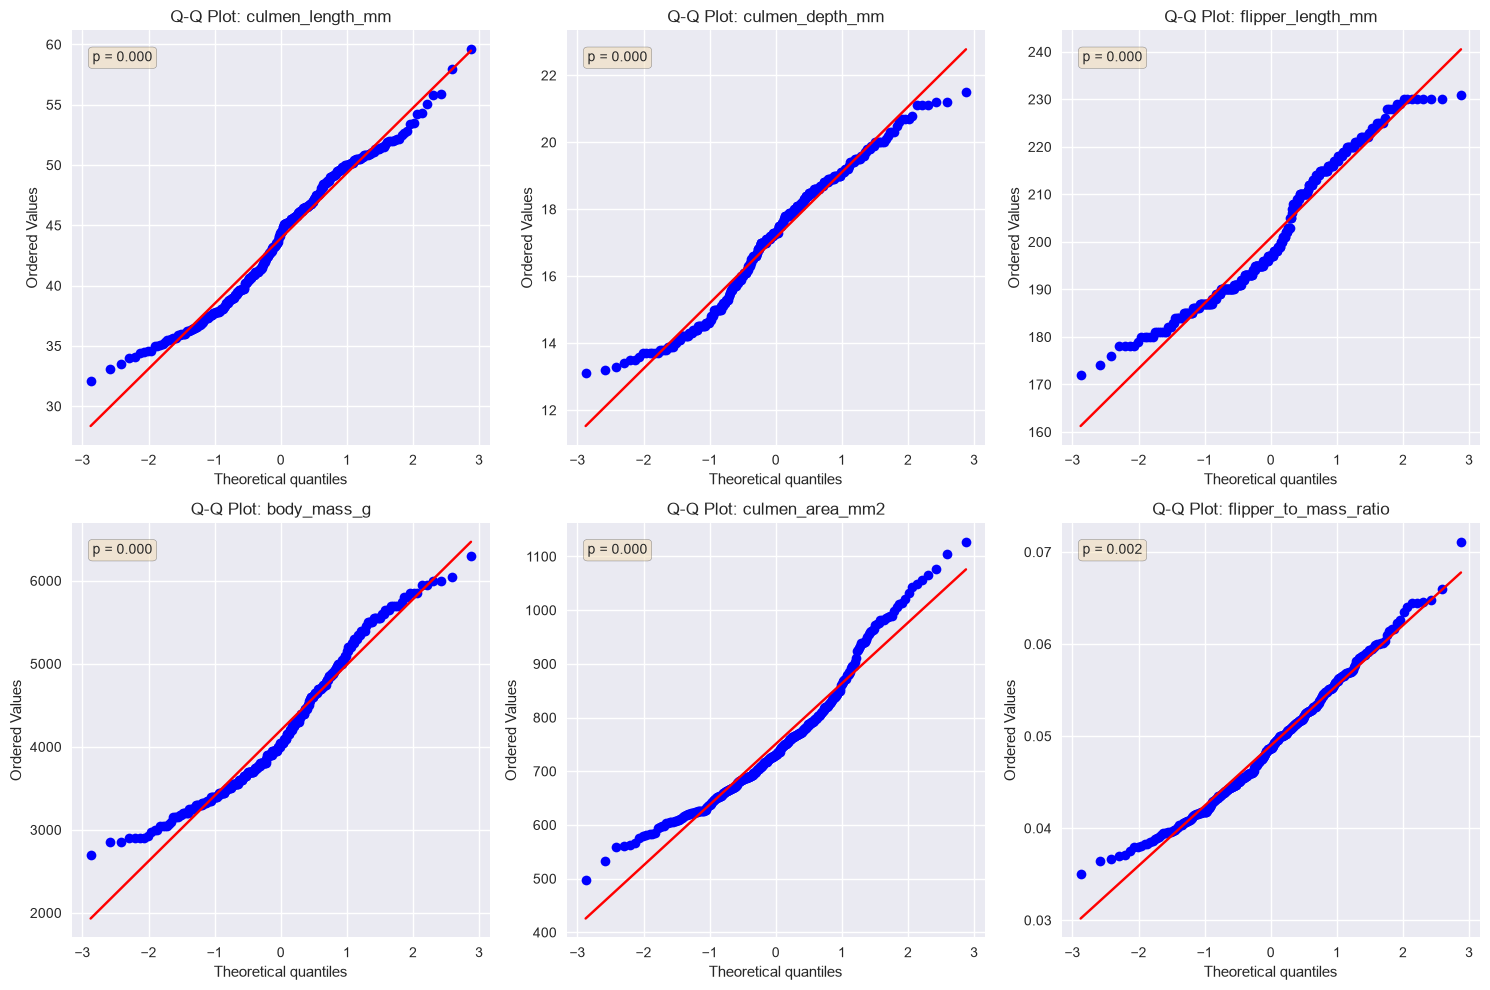

✅ All visualizations created successfully!


In [21]:
def create_qq_plots(df: pd.DataFrame):
    """Create Q-Q plots for numeric columns."""
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        data = df[col].dropna()
        stats.probplot(data, dist="norm", plot=axes[idx])
        axes[idx].set_title(f'Q-Q Plot: {col}')
        if len(data) > 3:
            _, p_value = stats.shapiro(data)
            axes[idx].text(0.05, 0.95, f'p = {p_value:.3f}',
                            transform=axes[idx].transAxes,
                            verticalalignment='top',
                            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.savefig('../reports/figures/qq_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

create_qq_plots(df)

print("✅ All visualizations created successfully!") 
